# Poker Dataset Exploration
Absolute Poker NLH 2009 â€” population study

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from parser import load_file, load_directory
from hand_utils import hand_summary, assign_positions, final_pot, count_preflop_raises

## Load hands

In [2]:
DATA_FILE = '../abs NLH handhq_1-OBFUSCATED.phhs'

hands = load_file(DATA_FILE)
print(f'Loaded {len(hands):,} hands')

Loaded 1,000 hands


## Build summary DataFrame

In [3]:
rows = [hand_summary(h) for h in hands]
df = pd.DataFrame(rows)
df.head()

,hand_id,file,date,table,n_players,pot_final,n_preflop_raises,went_to_showdown,is_multiway,n_actions,has_winnings
0,3017235114,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,DEFIANCE ST,5,1.50,0,False,False,9,True
1,3017237934,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,1.50,0,False,False,3,True
2,3017234966,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,MORGAN CT,6,3.25,1,False,False,12,True
3,3017238288,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,1.75,0,False,False,6,True
4,3017238782,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,2.50,1,False,False,4,True


In [4]:
df.describe()

,hand_id,n_players,pot_final,n_preflop_raises,n_actions
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.017338e+09,5.610000,11.708930,0.614000,18.157000
std,5.335087e+04,2.141141,18.094909,0.653782,7.998896
min,3.017235e+09,2.000000,1.000000,0.000000,3.000000
25%,3.017293e+09,5.000000,2.750000,0.000000,12.000000
50%,3.017341e+09,6.000000,4.750000,1.000000,18.000000
75%,3.017384e+09,7.000000,11.250000,1.000000,24.000000
max,3.017436e+09,9.000000,188.510000,5.000000,44.000000


## Player count distribution

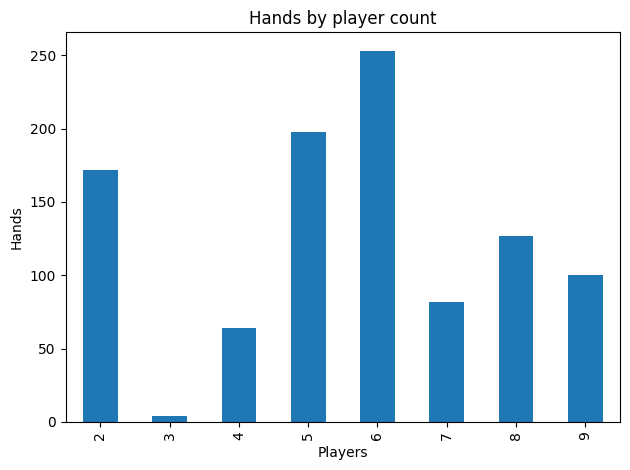

In [5]:
df['n_players'].value_counts().sort_index().plot(kind='bar', title='Hands by player count')
plt.xlabel('Players')
plt.ylabel('Hands')
plt.tight_layout()
plt.show()

## Pot size distribution

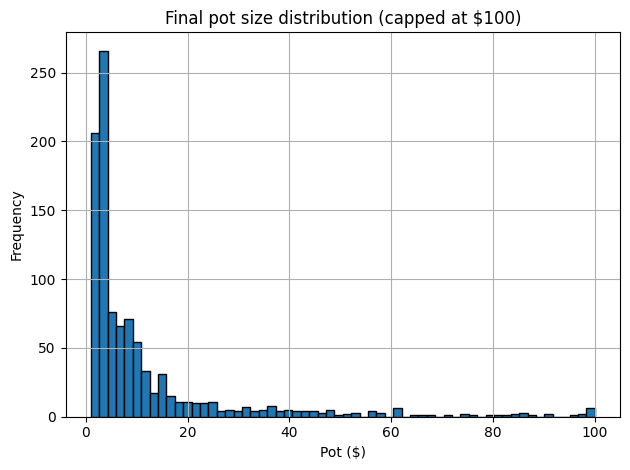

In [6]:
df['pot_final'].clip(upper=100).hist(bins=60, edgecolor='black')

plt.title('Final pot size distribution (capped at $100)')
plt.xlabel('Pot ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Preflop aggression

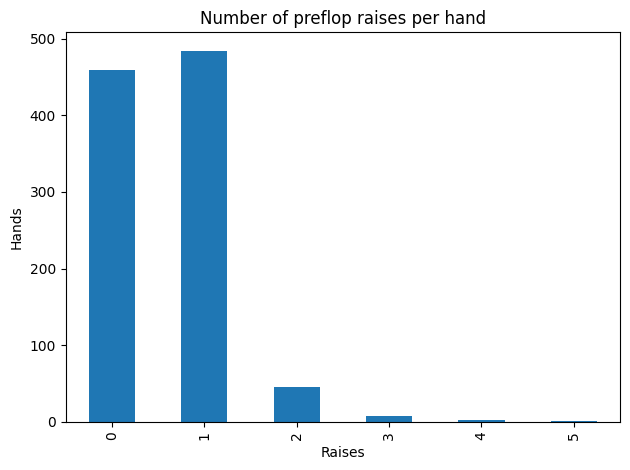

3bet+ rate: 5.7%
4bet+ rate: 1.1%


In [7]:
df['n_preflop_raises'].value_counts().sort_index().plot(
    kind='bar', title='Number of preflop raises per hand')
plt.xlabel('Raises')
plt.ylabel('Hands')
plt.tight_layout()
plt.show()

print('3bet+ rate: {:.1%}'.format((df['n_preflop_raises'] >= 2).mean()))
print('4bet+ rate: {:.1%}'.format((df['n_preflop_raises'] >= 3).mean()))

## Showdown rate

In [8]:
sd_rate = df['went_to_showdown'].mean()
print(f'Showdown rate: {sd_rate:.1%}')

Showdown rate: 29.2%


## Tables

In [9]:
df['table'].value_counts().head(20)

table
CAMERON ST     149
DEFIANCE ST    104
DOHENY AVE      97
ENGLAND AVE     92
JARVIS AVE      72
DAISY DR        70
MARINER DR      68
ALATNA AVE      64
CHAPEL HILL     63
BAGPIPE AVE     61
BRADFORD DR     54
MORGAN CT       42
CANADA HWY      41
GERMANY HWY     23
Name: count, dtype: int64

## Sample hand inspection

In [10]:
h = hands[20]   # change index to explore different hands
print(f'Hand {h.hand_id}  table={h.table}  date={h.date_str}')
print(f'Players ({h.n_players}): {h.players}')
print(f'Stacks: {h.starting_stacks}')
print(f'Blinds: {h.blinds_or_straddles}')
print(f'Winnings: {h.winnings}')
print()
print('Actions:')
for i, a in enumerate(h.actions):
    print(f'  [{i:2d}] {a}')

Hand 3017240534  table=DEFIANCE ST  date=2009-07-01
Players (5): ['C71mm6MhFIxjPW1vaAXL1g', '7cQYg8zQz/9uOLzp1GN8wQ', 'Qt5Yyd/Y121jtIk37c7TSg', 'l1bCLGuFqeFRwUfPsiDu/g', '13/ez0NPA4uRcBJ1Rafl6A']
Stacks: [54.8, 23.2, 12.07, 144.94, 17.15]
Blinds: [0.25, 0.5, 0.0, 0.0, 0.0]
Winnings: None

Actions:
  [ 0] d dh p1 ????
  [ 1] d dh p2 ????
  [ 2] d dh p3 ????
  [ 3] d dh p4 ????
  [ 4] d dh p5 ????
  [ 5] p3 f
  [ 6] p4 f
  [ 7] p5 cc
  [ 8] p1 cc
  [ 9] p2 cc
  [10] d db 7cAh7d
  [11] p1 cc
  [12] p2 cc
  [13] p5 cc
  [14] d db 4d
  [15] p1 cc
  [16] p2 cc
  [17] p5 cc
  [18] d db 4c
  [19] p1 cc
  [20] p2 cc
  [21] p5 cc
  [22] p1 sm 8c9s
  [23] p2 sm 8d5d
  [24] p5 sm Kd9h


## Run auto-labeller and check results

In [11]:
from labeller import label_hand, get_connection, insert_labels

conn = get_connection()
total_inserted = 0
for h in hands:
    rows_lbl = label_hand(h)
    total_inserted += insert_labels(rows_lbl, conn)
conn.close()
print(f'Inserted {total_inserted:,} label rows')

Inserted 0 label rows


In [12]:
from analyser import Analyser

an = Analyser()
print(an.summary())
print()

counts_df = an.label_counts_df()
counts_df

{'total_labelled_hands': 910, 'total_label_rows': 2207, 'unique_labels': 11}



,label,count
0,rfi,484
1,single_raised_pot,484
2,limp_pot,369
3,showdown,292
4,multi_way,280
5,cbet_flop,192
6,3bet_pot,46
7,check_raise_flop,23
8,all_in_preflop,18
9,4bet_pot,11


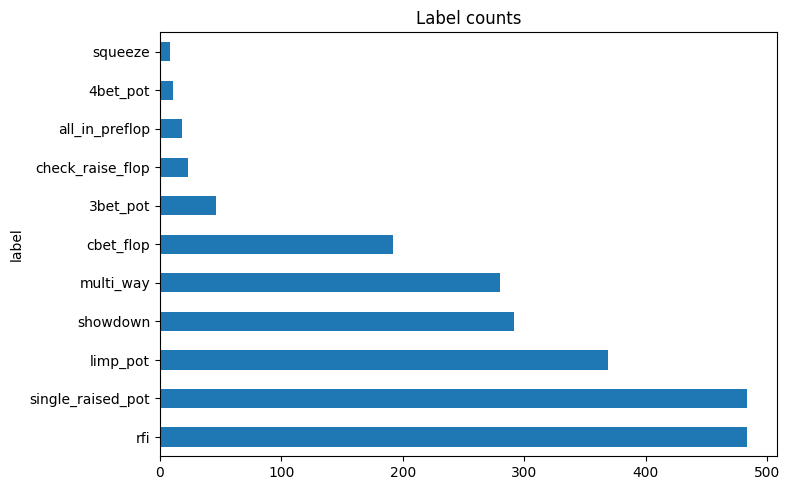

In [13]:
counts_df.set_index('label')['count'].plot(
    kind='barh', title='Label counts', figsize=(8, 5))
plt.tight_layout()
plt.show()

---
## Player earnings & filtering (`db/poker.db`)

Queries against the `player_hands` table populated by `src/ingest.py`.

In [14]:
import sqlite3

con = sqlite3.connect('../db/poker.db')
n_rows = con.execute('SELECT COUNT(*) FROM player_hands').fetchone()[0]
n_hands = con.execute('SELECT COUNT(DISTINCT hand_id) FROM player_hands').fetchone()[0]
print(f'{n_rows:,} player-hand rows across {n_hands:,} hands')

5,610 player-hand rows across 1,000 hands


### Earnings leaderboard

In [15]:
earnings = pd.read_sql("""
    SELECT player_id,
           COUNT(*)                        hands,
           ROUND(SUM(net_won), 2)          net_won,
           ROUND(AVG(net_won), 4)          avg_per_hand
    FROM player_hands
    WHERE net_won IS NOT NULL
    GROUP BY player_id
    HAVING hands >= 5
    ORDER BY net_won DESC
""", con)

print(f'Players with 5+ hands (net P&L): {len(earnings)}')
display(earnings.head(15))
print()
print('Top 10 losers:')
display(earnings.tail(10).iloc[::-1].reset_index(drop=True))

Players with 5+ hands (net P&L): 130


,player_id,hands,net_won,avg_per_hand
0,gaItR0R1G3KUo6rFvO7WSA,38,35.50,0.9342
1,pbvPI0stNwNAXy/QE1JAXg,111,31.30,0.2820
2,PYx3FTszINAM7LdMFQ1hEQ,50,22.21,0.4442
3,RPacPsXPMaT+YhUeKMrUfA,48,20.00,0.4167
4,nuxnmf7HL7MrAZNPlDDX1Q,30,15.50,0.5167
5,KLlJEYbTFCVjaXr5sAtg1A,32,13.90,0.4344
6,dpuysyVjg5o8joY5e6Ypuw,24,13.70,0.5708
7,3CgvSjQTVVVEaD5YGt19Fg,43,13.36,0.3107
8,QiLz8xreFvpFCuxIwseb6A,25,12.50,0.5000
9,8MD7/hkghOz++XhWHaw3SA,9,12.10,1.3444



Top 10 losers:


,player_id,hands,net_won,avg_per_hand
0,6HszwhCM3NdjslFq0876LQ,51,-40.90,-0.8020
1,VQrZtyzaWB7rSVrjHuNY3w,42,-25.45,-0.6060
2,5QbGWV+V6yxgRK17YY5Oxw,32,-20.50,-0.6406
3,6gZW0x7Ji/ISYLw4dAtEPg,123,-18.58,-0.1511
4,Wcffw5aUm+wgiW5RdXkPGw,45,-17.55,-0.3900
5,lUT2PLIfKHIvIkk5gqs9Cw,15,-16.60,-1.1067
6,dwm7OdwW0fVud6phTjHqtw,79,-16.00,-0.2025
7,5zrA/5h4aqvG/VAGOcFWqw,34,-14.85,-0.4368
8,m6ZVFj4FyFhk2DdaIkdIUA,48,-14.60,-0.3042
9,Pcbrz/bBnpt30AolVBpqjQ,36,-14.21,-0.3947


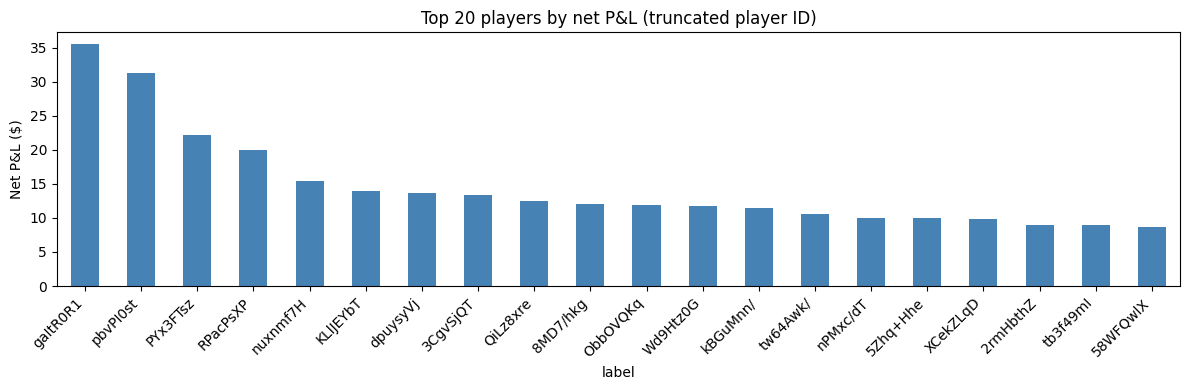

In [16]:
top20 = earnings.head(20).copy()
top20['label'] = top20['player_id'].str[:8]
top20.set_index('label')['net_won'].plot(
    kind='bar', figsize=(12, 4), color='steelblue',
    title='Top 20 players by net P&L (truncated player ID)')
plt.ylabel('Net P&L ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Rake analysis

Rake = `sum(invested) - sum(winnings)` per hand (only computable for hands where all winnings are known).
Each player's share is proportional to their investment in that hand.

In [17]:
# Per-hand rake (hands where every player's winnings are known)
rake_summary = pd.read_sql("""
    WITH hand_rake AS (
        SELECT hand_id,
               SUM(invested)              total_invested,
               SUM(winnings)              total_winnings,
               SUM(invested) - SUM(winnings) rake
        FROM player_hands
        GROUP BY hand_id
        HAVING SUM(CASE WHEN winnings IS NULL THEN 1 ELSE 0 END) = 0
    )
    SELECT COUNT(*)                         raked_hands,
           ROUND(SUM(rake), 2)              total_rake,
           ROUND(AVG(rake), 4)              avg_rake_per_hand,
           ROUND(AVG(100.0 * rake / total_invested), 2) avg_rake_pct
    FROM hand_rake
    WHERE rake >= 0
""", con).iloc[0]
print(f"Hands with known rake:  {int(rake_summary['raked_hands'])}")
print(f"Total rake collected:   ${rake_summary['total_rake']:.2f}")
print(f"Avg rake per hand:      ${rake_summary['avg_rake_per_hand']:.4f}")
print(f"Avg rake as % of pot:   {rake_summary['avg_rake_pct']:.2f}%")

# Per-player rake leaderboard
rake_df = pd.read_sql("""
    WITH hand_rake AS (
        SELECT hand_id,
               SUM(invested)                 total_invested,
               SUM(invested) - SUM(winnings) rake
        FROM player_hands
        GROUP BY hand_id
        HAVING SUM(CASE WHEN winnings IS NULL THEN 1 ELSE 0 END) = 0
          AND SUM(invested) - SUM(winnings) >= 0
    )
    SELECT ph.player_id,
           COUNT(*)                                                         hands,
           ROUND(SUM(ph.invested), 2)                                       total_invested,
           ROUND(SUM(hr.rake * ph.invested / hr.total_invested), 2)         rake_paid,
           ROUND(SUM(ph.net_won), 2)                                        net_won,
           ROUND(SUM(ph.net_won)
               + SUM(hr.rake * ph.invested / hr.total_invested), 2)         net_won_pre_rake
    FROM player_hands ph
    JOIN hand_rake hr ON ph.hand_id = hr.hand_id
    WHERE ph.net_won IS NOT NULL
    GROUP BY ph.player_id
    HAVING hands >= 5
    ORDER BY net_won_pre_rake DESC
""", con)

print(f'\nPlayers with 5+ hands (pre-rake leaderboard): {len(rake_df)}')
display(rake_df.head(15))
print()
print('Top 10 losers (pre-rake):')
display(rake_df.tail(10).iloc[::-1].reset_index(drop=True))

Hands with known rake:  596
Total rake collected:   $168.55
Avg rake per hand:      $0.2828
Avg rake as % of pot:   4.67%

Players with 5+ hands (pre-rake leaderboard): 125


,player_id,hands,total_invested,rake_paid,net_won,net_won_pre_rake
0,pbvPI0stNwNAXy/QE1JAXg,96,102.75,7.49,32.80,40.29
1,gaItR0R1G3KUo6rFvO7WSA,37,55.25,4.15,35.00,39.15
2,PYx3FTszINAM7LdMFQ1hEQ,40,48.74,4.22,21.21,25.43
3,RPacPsXPMaT+YhUeKMrUfA,33,91.70,2.20,19.50,21.70
4,nuxnmf7HL7MrAZNPlDDX1Q,30,21.75,2.04,15.50,17.54
5,dpuysyVjg5o8joY5e6Ypuw,21,24.25,1.89,13.95,15.84
6,Wd9Htz0GbMHBY3OMflyeiQ,13,22.25,1.89,12.75,14.64
7,8MD7/hkghOz++XhWHaw3SA,9,19.00,1.59,12.10,13.69
8,nPMxc/dTTPlTQ8xVauNXhA,38,40.50,3.29,10.05,13.34
9,kBGuMnn/Rct610s8l5B3AQ,22,19.50,1.65,11.65,13.30



Top 10 losers (pre-rake):


,player_id,hands,total_invested,rake_paid,net_won,net_won_pre_rake
0,6HszwhCM3NdjslFq0876LQ,51,67.55,5.00,-40.90,-35.90
1,dwm7OdwW0fVud6phTjHqtw,53,106.70,2.95,-27.50,-24.55
2,VQrZtyzaWB7rSVrjHuNY3w,34,43.00,2.76,-24.70,-21.94
3,5QbGWV+V6yxgRK17YY5Oxw,32,24.25,1.66,-20.50,-18.84
4,lUT2PLIfKHIvIkk5gqs9Cw,15,19.00,1.43,-16.60,-15.17
5,Wcffw5aUm+wgiW5RdXkPGw,41,24.50,1.50,-16.30,-14.80
6,Pcbrz/bBnpt30AolVBpqjQ,34,41.61,3.04,-17.71,-14.67
7,5zrA/5h4aqvG/VAGOcFWqw,28,36.75,2.44,-16.40,-13.96
8,m6ZVFj4FyFhk2DdaIkdIUA,46,23.50,1.61,-15.10,-13.49
9,6gZW0x7Ji/ISYLw4dAtEPg,103,57.87,4.14,-17.58,-13.44


### Positional profitability

In [18]:
pos_stats = pd.read_sql("""
    SELECT position,
           n_players,
           COUNT(*)                                              hands,
           ROUND(SUM(net_won), 2)                               net_won,
           ROUND(AVG(net_won), 4)                               avg_per_hand,
           ROUND(100.0 * SUM(saw_flop)   / COUNT(*), 1)        flop_seen_pct,
           ROUND(100.0 * SUM(went_to_sd) / COUNT(*), 1)        showdown_pct
    FROM player_hands
    GROUP BY position, n_players ORDER BY n_players, net_won DESC
""", con)
pos_stats

,position,n_players,hands,net_won,avg_per_hand,flop_seen_pct,showdown_pct
0,BTN,2,172,33.50,0.2481,84.3,23.3
1,BB,2,172,-20.75,-0.1537,76.2,21.5
2,BTN,3,4,0.95,0.9500,25.0,0.0
3,BB,3,4,-0.50,-0.5000,100.0,75.0
4,SB,3,4,-0.50,-0.5000,100.0,75.0
5,UTG,4,64,3.10,0.0660,31.3,4.7
6,SB,4,64,-0.80,-0.0170,42.2,12.5
7,BTN,4,64,-2.30,-0.0489,40.6,15.6
8,BB,4,64,-6.90,-0.1468,73.4,20.3
9,UTG,5,198,52.60,0.3628,28.3,6.6


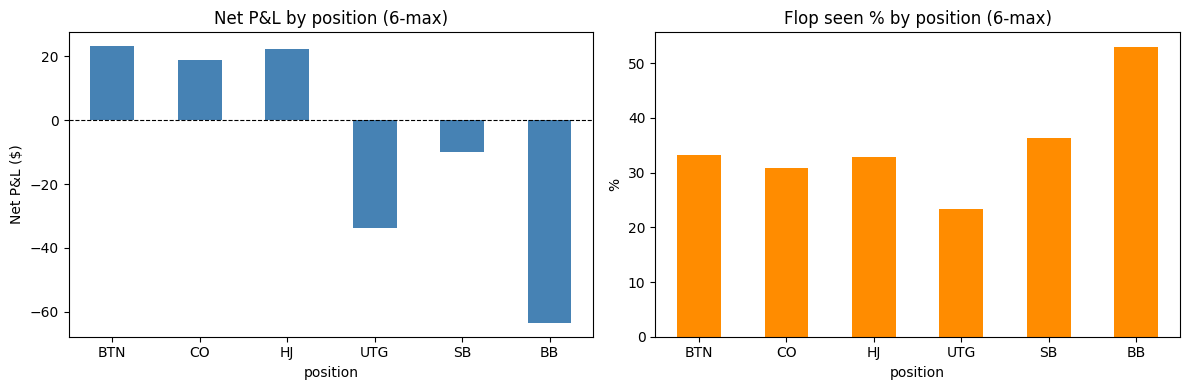

In [19]:
# Chart uses 6-max hands only (n_players == 6) so positions are comparable
pos_order = ['BTN', 'CO', 'HJ', 'UTG', 'SB', 'BB']
ps6 = (pos_stats[pos_stats['n_players'] == 6]
       .set_index('position')
       .reindex(pos_order))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ps6['net_won'].plot(kind='bar', ax=axes[0], color='steelblue',
                    title='Net P&L by position (6-max)')
axes[0].set_ylabel('Net P&L ($)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=0)

ps6['flop_seen_pct'].plot(kind='bar', ax=axes[1], color='darkorange',
                           title='Flop seen % by position (6-max)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Earnings by pot type

Join `player_hands` with `labels` to slice stats by preflop situation.

In [20]:
pot_types = ['limp_pot', 'single_raised_pot', '3bet_pot', '4bet_pot', 'squeeze']
rows = []
for label in pot_types:
    r = pd.read_sql("""
        SELECT COUNT(DISTINCT ph.hand_id)              unique_hands,
               ROUND(SUM(ph.net_won), 2)               net_won,
               ROUND(100.0 * SUM(ph.went_to_sd)
                     / COUNT(*), 1)                    sd_pct,
               ROUND(100.0 * SUM(ph.saw_flop)
                     / COUNT(*), 1)                    flop_seen_pct
        FROM player_hands ph
        JOIN labels l ON ph.hand_id = l.hand_id
        WHERE l.label = ? AND ph.net_won IS NOT NULL
    """, con, params=[label]).iloc[0].to_dict()
    r['pot_type'] = label
    rows.append(r)

pd.DataFrame(rows).set_index('pot_type')

,unique_hands,net_won,sd_pct,flop_seen_pct
pot_type,,,,
limp_pot,230.0,-41.60,0.3,50.2
single_raised_pot,371.0,-92.35,0.4,29.2
3bet_pot,29.0,-16.65,0.6,27.6
4bet_pot,2.0,0.00,0.0,20.0
squeeze,1.0,0.00,0.0,16.7


### Player deep-dive

Break down the top earner's results by position and situation type.

In [21]:
top_pid     = earnings.iloc[0]['player_id']
top_net_won = earnings.iloc[0]['net_won']
top_hands   = earnings.iloc[0]['hands']
print(f'Player:  {top_pid}')
print(f'Net P&L: ${top_net_won:.2f} across {top_hands} hands  (${top_net_won/top_hands:.2f}/hand avg)')

print('\nNet P&L by position:')
display(pd.read_sql("""
    SELECT position,
           COUNT(*)                                    hands,
           ROUND(SUM(net_won), 2)                      net_won,
           ROUND(100.0 * SUM(saw_flop) / COUNT(*), 1)  flop_seen_pct
    FROM player_hands
    WHERE player_id = ? AND net_won IS NOT NULL
    GROUP BY position ORDER BY net_won DESC
""", con, params=[top_pid]))

print('\nNet P&L by situation label:')
display(pd.read_sql("""
    SELECT l.label,
           COUNT(*)                       hands,
           ROUND(SUM(ph.net_won), 2)      net_won
    FROM player_hands ph
    JOIN labels l ON ph.hand_id = l.hand_id
    WHERE ph.player_id = ? AND ph.net_won IS NOT NULL
    GROUP BY l.label ORDER BY net_won DESC
""", con, params=[top_pid]))

Player:  gaItR0R1G3KUo6rFvO7WSA
Net P&L: $35.50 across 38 hands  ($0.93/hand avg)

Net P&L by position:


,position,hands,net_won,flop_seen_pct
0,BTN,7,21.80,100.0
1,BB,7,6.60,85.7
2,SB,6,5.60,100.0
3,HJ,2,2.05,50.0
4,CO,8,1.65,75.0
5,UTG,8,-2.20,75.0



Net P&L by situation label:


,label,hands,net_won
0,single_raised_pot,22,36.85
1,rfi,22,36.85
2,multi_way,12,15.55
3,cbet_flop,9,10.35
4,limp_pot,14,4.15
5,check_raise_flop,1,3.20
6,3bet_pot,1,-6.00
